# Employee Data Cleaning and Preprocessing Pipeline

## Internship Task 01

### Objective
The objective of this project is to clean and preprocess an employee dataset by handling missing values, removing duplicate records, correcting inconsistent data formats, and preparing the dataset for analysis and machine learning.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Missingno
- Scikit-learn
- JupyterLab

## Table of Contents

1. Loading Dataset
2. Initial Dataset Inspection
3. Data Quality Assessment
4. Data Cleaning Strategy
5. Handling Missing Values
6. Verification
7. Data Type Validation
8. Feature Engineering
9. Text Standardization
10. Final Dataset Summary
11. Export Clean Dataset
12. Before vs After Comparison
13. Final Data Quality Report
14. Data Visualization
15. Conclusion

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Display plots inside notebook
%matplotlib inline

# Step 1: Loading the Dataset

The first step in any data science project is to load the dataset into a Pandas DataFrame. This allows us to inspect, clean, analyze, and preprocess the data.

In [2]:

# Step 1: Load the Dataset
# Load the CSV file

df = pd.read_csv("data/netflix_titles.csv")

# Confirmation message
print("Dataset loaded successfully!")

Dataset loaded successfully!


# Step 2: Initial Dataset Inspection

Before cleaning the dataset, it is important to understand its structure, size, columns, data types, and overall quality.

In [3]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
# Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Number of Unique Values in Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns

unique_values = pd.DataFrame({
    "Column": categorical_columns,
    "Unique Values": [df[col].nunique() for col in categorical_columns]
})

unique_values

C:\Users\SarthakVats\AppData\Local\Temp\ipykernel_16368\3203983496.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


,Column,Unique Values
0,show_id,8807
1,type,2
2,title,8804
3,director,4528
4,cast,7692
5,country,748
6,date_added,1767
7,rating,17
8,duration,220
9,listed_in,514


# Step 3: Data Quality Assessment

Data quality assessment is the process of identifying issues in the dataset before cleaning it.

In this step, we will:

- Check missing values
- Check duplicate records
- Examine data types
- Identify unique values in categorical columns
- Visualize missing data

These checks help us decide the most appropriate preprocessing techniques.

In [10]:

# Missing Value Report

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_report = missing_report.sort_values(
    by="Missing Values",
    ascending=False
)

missing_report

,Missing Values,Percentage (%)
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [11]:
# Duplicate Records

duplicate_rows = df.duplicated().sum()

print(f"Total Duplicate Rows : {duplicate_rows}")

Total Duplicate Rows : 0


In [12]:
# Data Types

dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_report

,Column,Data Type
0,show_id,str
1,type,str
2,title,str
3,director,str
4,cast,str
5,country,str
6,date_added,str
7,release_year,int64
8,rating,str
9,duration,str


In [13]:
# Unique Values

categorical_columns = df.select_dtypes(include="object").columns

unique_report = pd.DataFrame({
    "Column": categorical_columns,
    "Unique Values":
    [df[col].nunique() for col in categorical_columns]
})

unique_report

C:\Users\SarthakVats\AppData\Local\Temp\ipykernel_16368\3688216927.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


,Column,Unique Values
0,show_id,8807
1,type,2
2,title,8804
3,director,4528
4,cast,7692
5,country,748
6,date_added,1767
7,rating,17
8,duration,220
9,listed_in,514


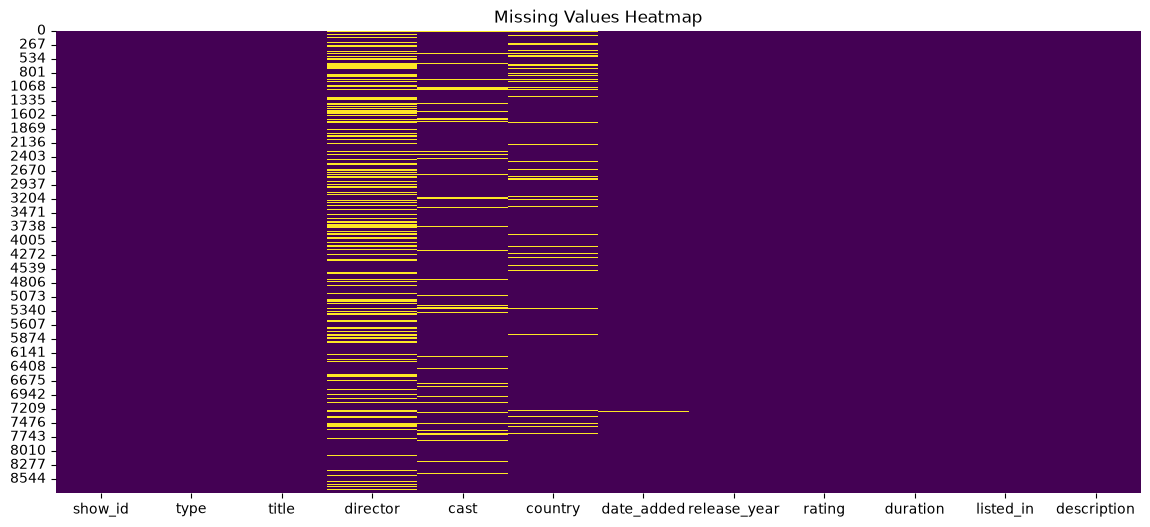

In [14]:
# Missing Value Heatmap

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

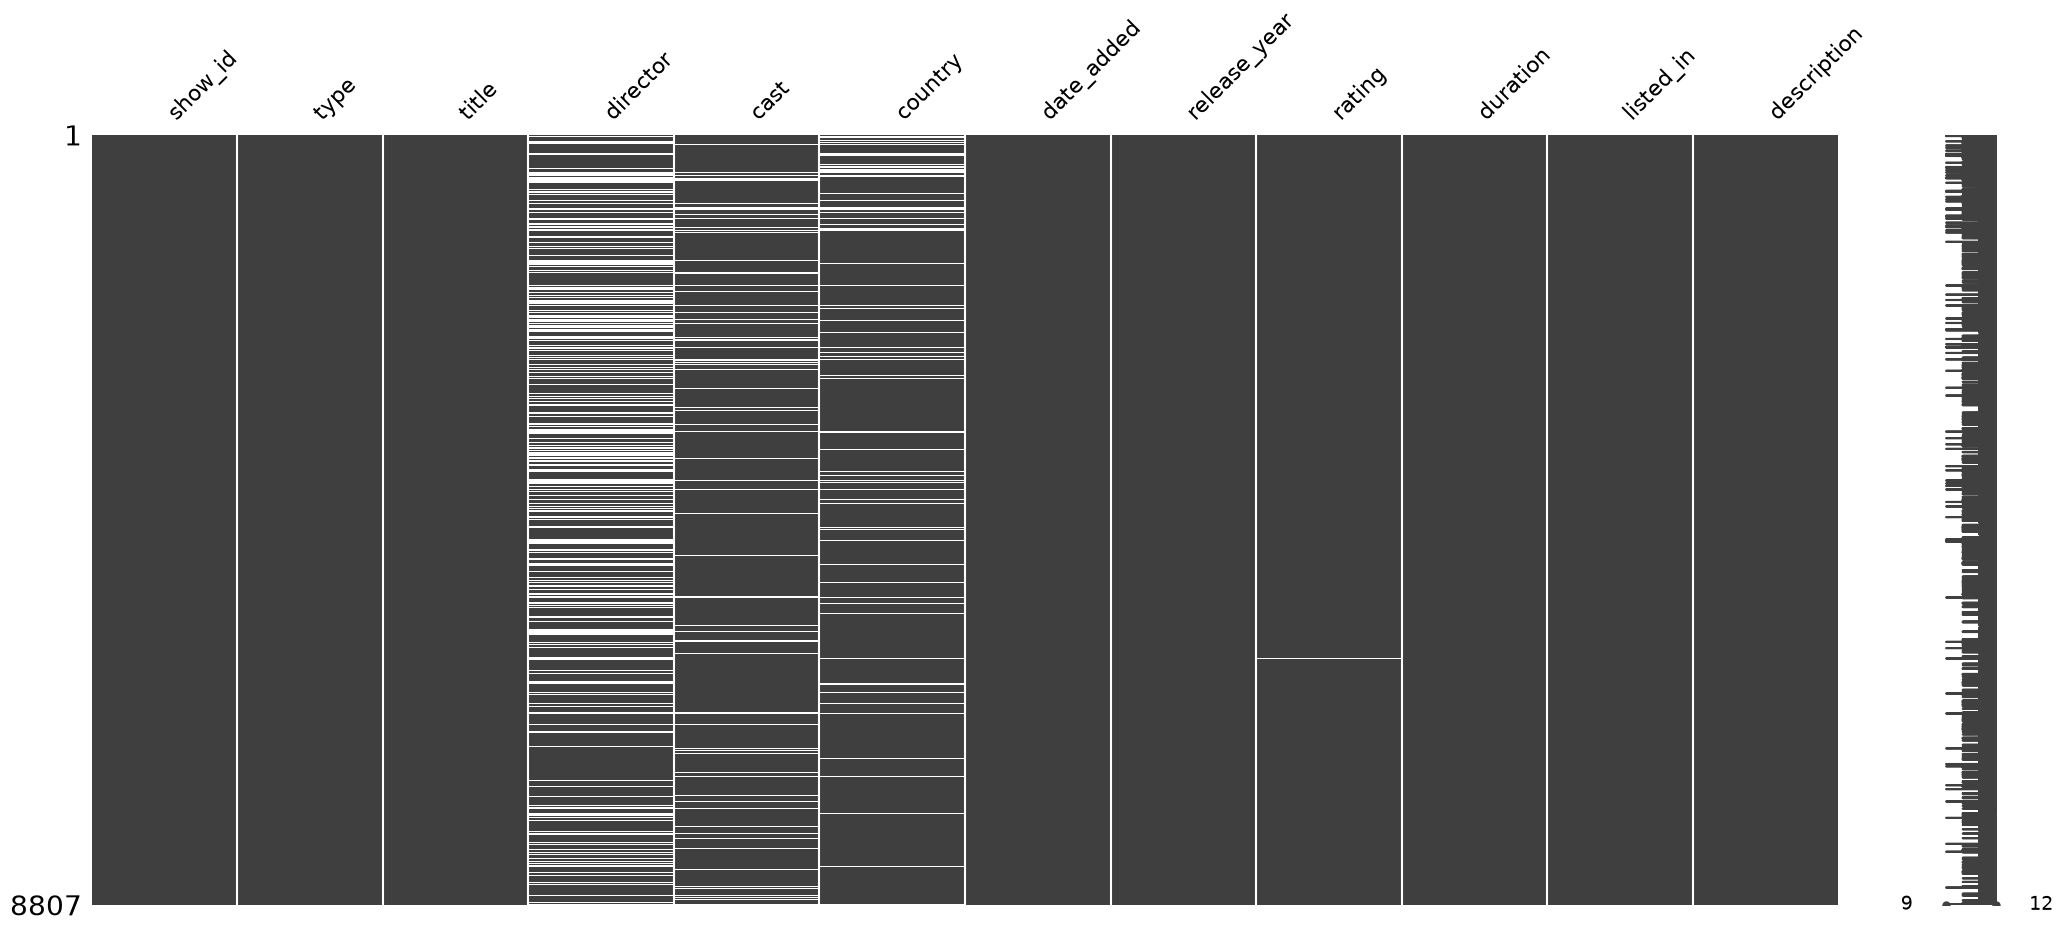

In [15]:
# Missing Value Matrix

msno.matrix(df)

plt.show()

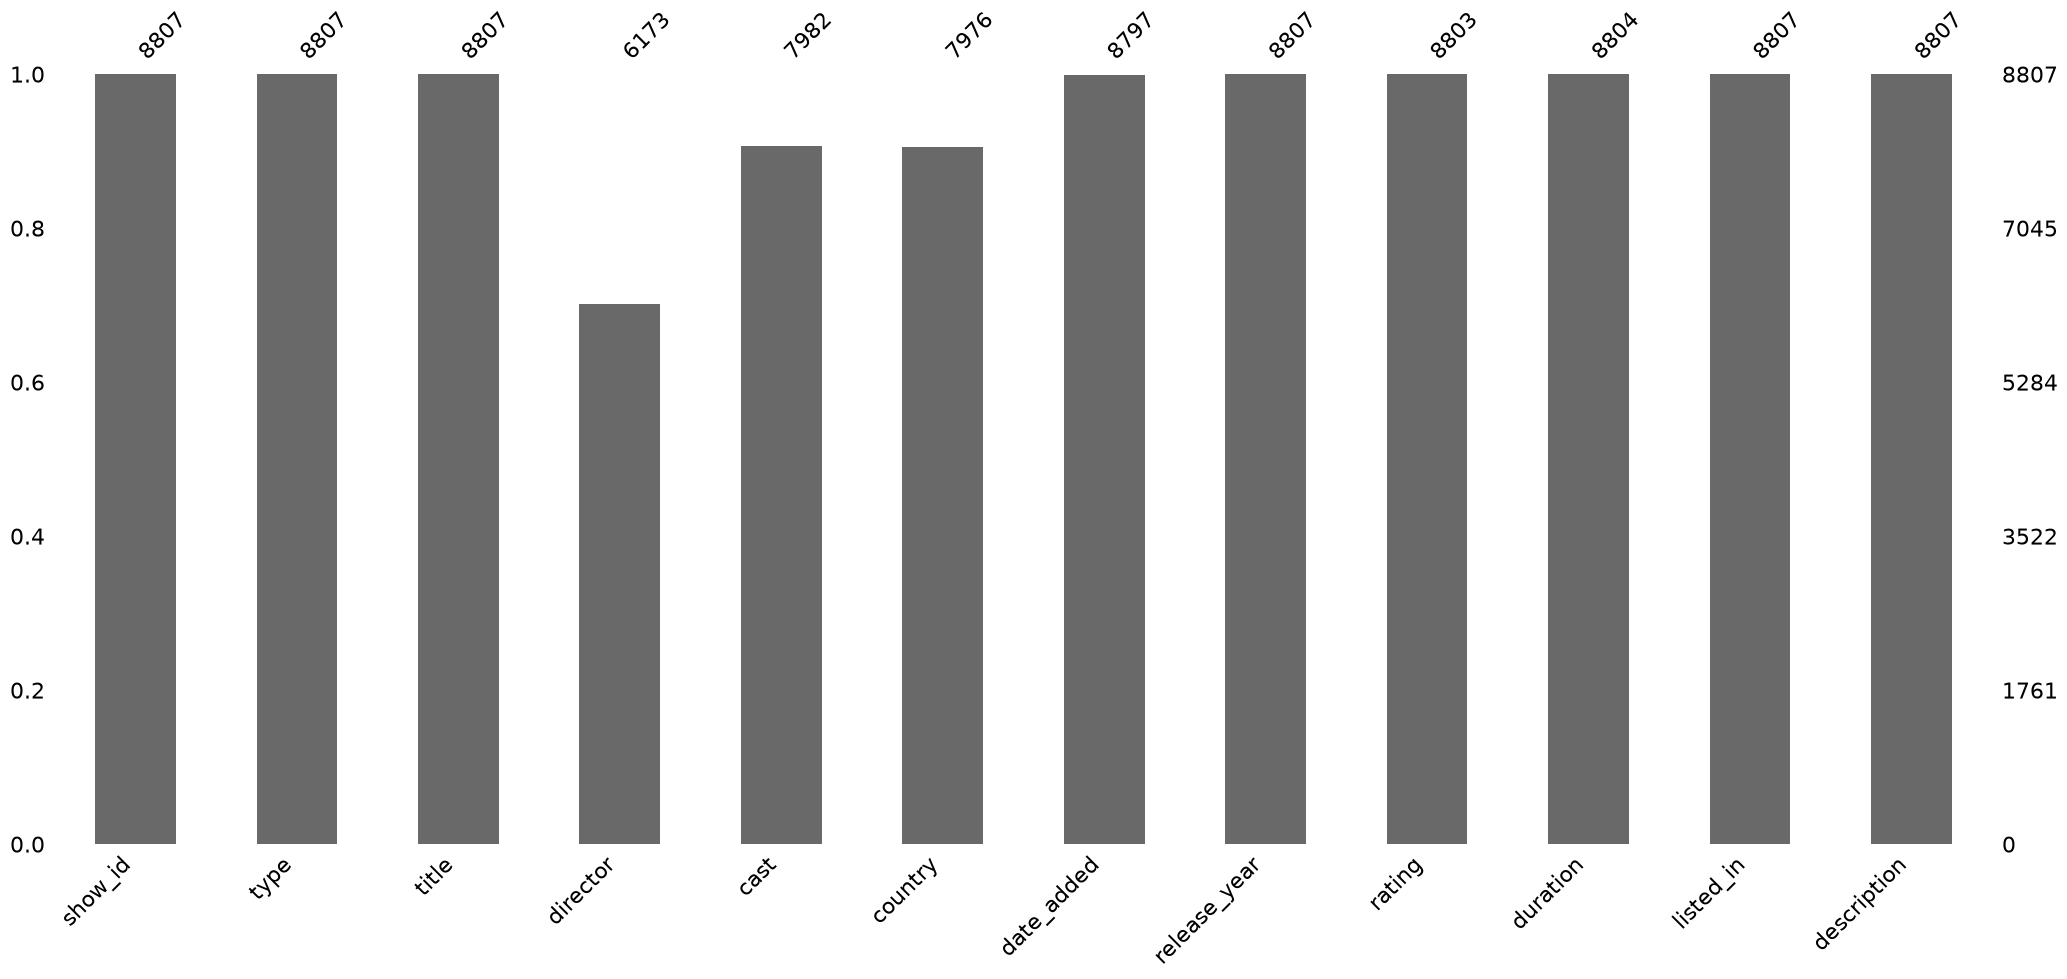

In [16]:
# Missing Value Bar Graph

msno.bar(df)

plt.show()

In [17]:
# Dataset Memory Usage

memory = df.memory_usage(deep=True)

memory_df = pd.DataFrame({
    "Column": memory.index,
    "Memory (Bytes)": memory.values
})

memory_df

,Column,Memory (Bytes)
0,Index,132
1,show_id,474471
2,type,480930
3,title,599151
4,director,488185
5,cast,1422387
6,country,517757
7,date_added,561028
8,release_year,70456
9,rating,470514


# Step 4: Data Cleaning Strategy

Based on the data quality assessment, the following preprocessing strategy will be applied:

| Column | Problem | Solution |
|--------|---------|----------|
| director | Missing values | Replace with "Unknown" |
| cast | Missing values | Replace with "Unknown" |
| country | Missing values | Replace with mode |
| date_added | Missing values | Fill with mode and convert to datetime |
| rating | Missing values | Fill with mode |
| duration | Missing values | Fill with mode |
| Duplicate Records | None found | No action required |

This strategy ensures that important information is preserved while making the dataset suitable for analysis and machine learning.

## Step 5: Handling Missing Values

### 5.1 Cleaning the Director Column
The **director** column contains **2634 missing values**, which is the highest among all columns.

Removing these rows would lead to a significant loss of data. Therefore, missing values are replaced with **"Unknown"** to preserve all movie and TV show records while clearly indicating unavailable information.

In [18]:
# Cleaning the Director Column

# Missing values before cleaning
print("Missing values before:", df["director"].isnull().sum())

# Replace missing values
df["director"] = df["director"].fillna("Unknown")

# Missing values after cleaning
print("Missing values after:", df["director"].isnull().sum())

Missing values before: 2634
Missing values after: 0


### 5.2 Cleaning the Cast Column

The **cast** column contains missing values for some movies and TV shows.

Instead of removing these records, missing values are replaced with **"Unknown"** so that all records remain available for analysis.

In [19]:
# Cleaning the Cast Column

print("Missing values before:", df["cast"].isnull().sum())

df["cast"] = df["cast"].fillna("Unknown")

print("Missing values after:", df["cast"].isnull().sum())

Missing values before: 825
Missing values after: 0


### 5.3 Cleaning the Country Column

The **country** column contains missing values.

Since the number of missing values is relatively small compared to the size of the dataset, missing entries are replaced with the **most frequently occurring country (mode)** to maintain consistency.

In [20]:
# Cleaning the Country Column

print("Missing values before:", df["country"].isnull().sum())

country_mode = df["country"].mode()[0]

df["country"] = df["country"].fillna(country_mode)

print("Most Frequent Country:", country_mode)

print("Missing values after:", df["country"].isnull().sum())

Missing values before: 831
Most Frequent Country: United States
Missing values after: 0


### 5.4 Cleaning the Date Added Column

The **date_added** column contains only **10 missing values**.

Since this column stores dates, missing values are first replaced with the **most frequently occurring date (mode)**. After handling missing values, the column is converted into the **datetime** format to enable date-based analysis and improve consistency.

In [21]:
# Cleaning the Date Added Column

print("Missing values before:", df["date_added"].isnull().sum())

# Fill missing values with mode
date_mode = df["date_added"].mode()[0]
df["date_added"] = df["date_added"].fillna(date_mode)

# Convert to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed"
)

print("Missing values after:", df["date_added"].isnull().sum())

print("\nData Type:")
print(df["date_added"].dtype)

Missing values before: 10
Missing values after: 0

Data Type:
datetime64[us]


### 5.5 Cleaning the Rating Column

The **rating** column contains only **4 missing values**.

Since the number of missing values is very small, they are replaced with the **most frequently occurring rating (mode)** to maintain consistency in the dataset.

In [22]:
# Cleaning the Rating Column

before = df["rating"].isnull().sum()

rating_mode = df["rating"].mode()[0]

df["rating"] = df["rating"].fillna(rating_mode)

after = df["rating"].isnull().sum()

print(f"Rating: {before} → {after}")
print(f"Mode Used: {rating_mode}")

Rating: 4 → 0
Mode Used: TV-MA


### 5.6 Cleaning the Duration Column

The **duration** column contains only **3 missing values**.

To preserve all records, the missing values are replaced with the **most frequently occurring duration (mode)**.

In [23]:
# Cleaning the Duration Column

before = df["duration"].isnull().sum()

duration_mode = df["duration"].mode()[0]

df["duration"] = df["duration"].fillna(duration_mode)

after = df["duration"].isnull().sum()

print(f"Duration: {before} → {after}")
print(f"Mode Used: {duration_mode}")

Duration: 3 → 0
Mode Used: 1 Season


# Step 6: Verification of Data Cleaning

After handling all missing values, a final verification is performed to ensure that the dataset no longer contains any missing values.

In [24]:
# Final Missing Value Verification

final_missing = pd.DataFrame({
    "Missing Values": df.isnull().sum()
})

final_missing

,Missing Values
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [25]:
# Cleaning Status

if df.isnull().sum().sum() == 0:
    print("Data cleaning completed successfully.")
    print("The dataset contains no missing values.")
else:
    print("Some missing values still exist.")

Data cleaning completed successfully.
The dataset contains no missing values.


# Step 7: Data Type Validation

After handling missing values, the next step is to verify that each column has the appropriate data type.

Correct data types improve memory efficiency, ensure accurate analysis, and prepare the dataset for future machine learning tasks.

In [26]:
# Data Type Validation

dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_report

,Column,Data Type
0,show_id,str
1,type,str
2,title,str
3,director,str
4,cast,str
5,country,str
6,date_added,datetime64[us]
7,release_year,int64
8,rating,str
9,duration,str


# Step 8: Feature Engineering

The **date_added** column contains valuable information that can be split into separate features.

Three new columns are created:

- Added Year
- Added Month
- Added Day

These features can be useful for trend analysis and future machine learning models.

In [27]:
# Feature Engineering

df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month
df["added_day"] = df["date_added"].dt.day

print("New Features Created Successfully!")

df[["date_added", "added_year", "added_month", "added_day"]].head()

New Features Created Successfully!


,date_added,added_year,added_month,added_day
0,2021-09-25,2021,9,25
1,2021-09-24,2021,9,24
2,2021-09-24,2021,9,24
3,2021-09-24,2021,9,24
4,2021-09-24,2021,9,24


# Step 9: Text Standardization

Text columns may contain unnecessary leading or trailing spaces.

Removing these spaces ensures consistency and improves data quality.

In [28]:
# Text Standardization

text_columns = [
    "title",
    "director",
    "cast",
    "country",
    "rating",
    "listed_in"
]

for col in text_columns:
    df[col] = df[col].str.strip()

print("Text Standardization Completed Successfully!")

Text Standardization Completed Successfully!


# Step 10: Final Dataset Summary

After cleaning and preprocessing, the dataset is inspected one final time to verify that all transformations have been applied successfully.

In [29]:
# Final Dataset Summary

print("Dataset Shape:", df.shape)

print("\n")

df.info()

Dataset Shape: (8807, 15)


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8807 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
 12  added_year    8807 non-null   int32         
 13  added_month   8807 non-null   int32         
 14  added_day     8807 non-null   int32         
dtypes: datetime64[us](1),

# Step 11: Export Clean Dataset

The cleaned and preprocessed dataset is exported as a CSV file for future analysis and machine learning tasks.

In [30]:
# Export Clean Dataset

output_path = "output/netflix_titles_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset exported successfully!")

print("Location:", output_path)

Cleaned dataset exported successfully!
Location: output/netflix_titles_cleaned.csv


# Step 12: Before vs After Comparison

The table below summarizes the improvements made during the data cleaning and preprocessing process.

In [31]:
comparison = pd.DataFrame({
    "Metric": [
        "Missing Values",
        "Duplicate Rows",
        "Date Column Type",
        "New Features Created",
        "Dataset Ready for Analysis"
    ],
    "Before": [
        4307,
        0,
        "Object",
        0,
        "No"
    ],
    "After": [
        0,
        0,
        "Datetime",
        3,
        "Yes"
    ]
})

comparison

,Metric,Before,After
0,Missing Values,4307,0
1,Duplicate Rows,0,0
2,Date Column Type,Object,Datetime
3,New Features Created,0,3
4,Dataset Ready for Analysis,No,Yes


# Final Cleaned Dataset Preview

The first five rows of the cleaned dataset are displayed below.

In [32]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,24
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8807 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
 12  added_year    8807 non-null   int32         
 13  added_month   8807 non-null   int32         
 14  added_day     8807 non-null   int32         
dtypes: datetime64[us](1), int32(3), int64(1), str(10)

In [34]:
# Final Data Quality Report

final_report = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Date Added Type"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["date_added"].dtype
    ]
})

final_report

,Metric,Value
0,Total Rows,8807
1,Total Columns,15
2,Missing Values,0
3,Duplicate Rows,0
4,Date Added Type,datetime64[us]


# Step 14: Data Visualization

After cleaning and preprocessing the dataset, a few visualizations are created to verify the quality of the cleaned data and understand the overall distribution of the dataset.

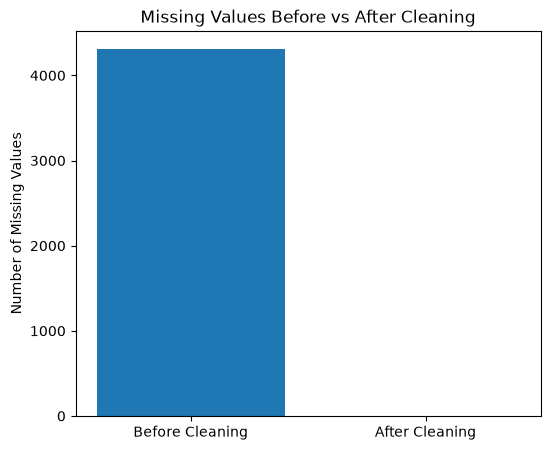

In [35]:
# Missing Values Before vs After

before_missing = 4307
after_missing = df.isnull().sum().sum()

plt.figure(figsize=(6,5))

plt.bar(
    ["Before Cleaning", "After Cleaning"],
    [before_missing, after_missing]
)

plt.title("Missing Values Before vs After Cleaning")
plt.ylabel("Number of Missing Values")

plt.show()

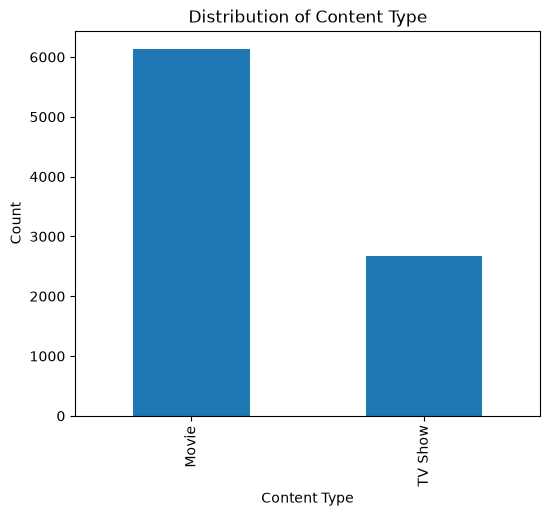

In [36]:
# Content Type Distribution

plt.figure(figsize=(6,5))

df["type"].value_counts().plot(kind="bar")

plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

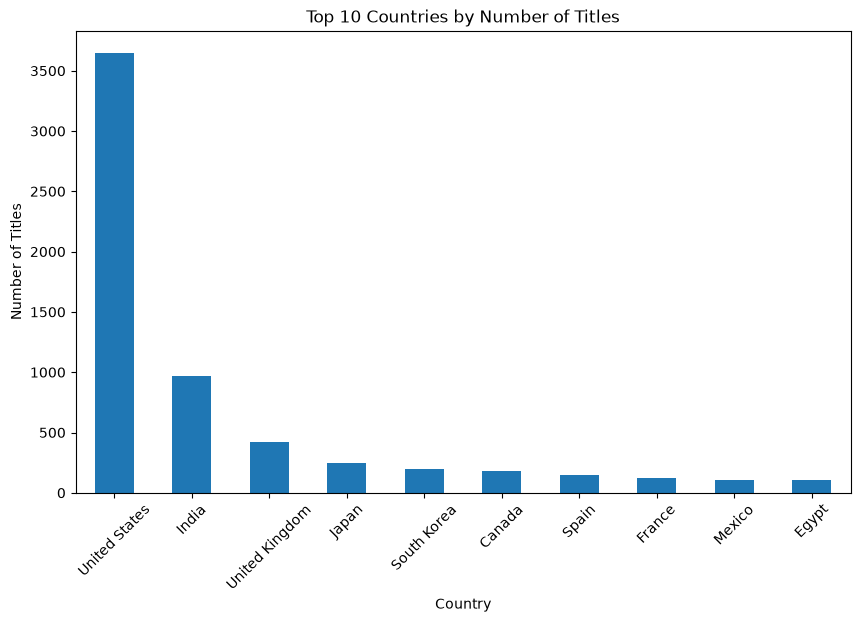

In [37]:
# Top 10 Countries

top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

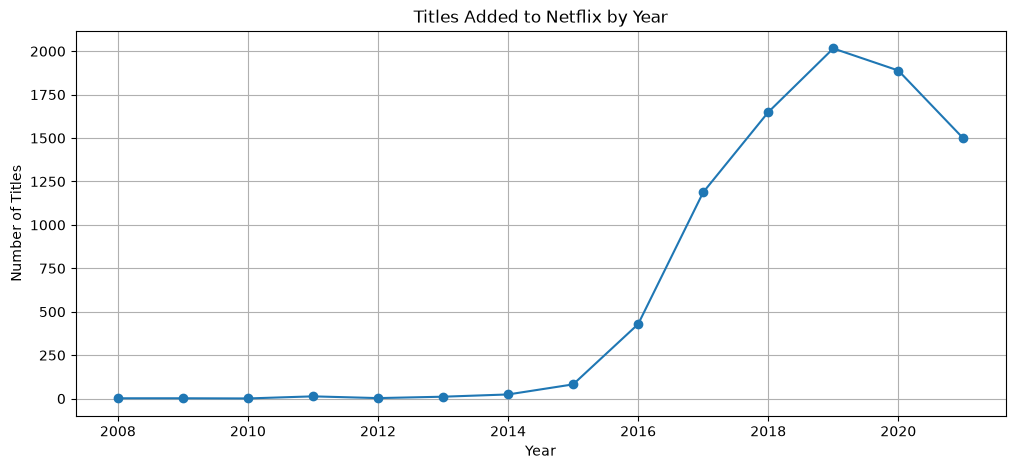

In [38]:
# Titles Added by Year

titles_per_year = df["added_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

titles_per_year.plot(kind="line", marker="o")

plt.title("Titles Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

# Conclusion

This project successfully implemented a complete Data Cleaning and Preprocessing Pipeline using the Netflix Movies and TV Shows dataset.

The dataset was inspected, cleaned, and preprocessed by handling missing values, validating data types, creating new features, standardizing text data, and exporting a cleaned dataset.

### Final Results

- Total Records: **8807**
- Total Columns: **15**
- Missing Values Remaining: **0**
- Duplicate Records: **0**

The cleaned dataset is now ready for exploratory data analysis and machine learning applications.